In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import xgboost as xgb

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
train = pd.read_csv(r"C:\Users\kalug\Downloads\NSL KDD\train.csv")
test = pd.read_csv(r"C:\Users\kalug\Downloads\NSL KDD\test.csv")

In [5]:
df = pd.concat([train, test], ignore_index=True)

# Separate target
y = df.iloc[:, -1]
X = df.iloc[:, :-1]

# Encode categorical columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target
y = LabelEncoder().fit_transform(y)

C:\Users\kalug\AppData\Local\Temp\ipykernel_29472\3015585053.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [9]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

c:\Users\kalug\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:00:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [10]:
final_pred = (rf_pred + xgb_pred) // 2

In [11]:
print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred, average='weighted'))
print("Recall:", recall_score(y_test, final_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, final_pred, average='weighted'))

Accuracy: 0.9964162535029101
Precision: 0.9964162635122712
Recall: 0.9964162535029101
F1 Score: 0.9964162519963069


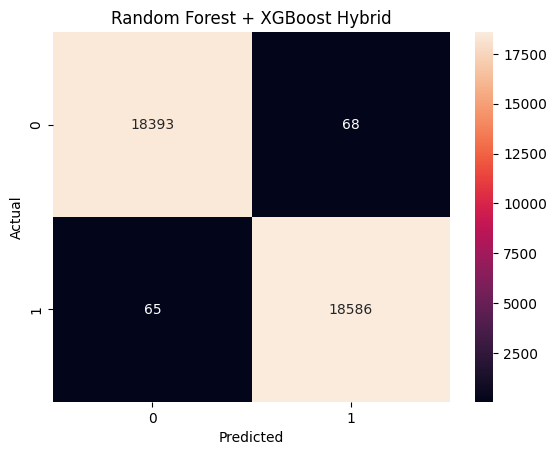

In [12]:
cm = confusion_matrix(y_test, final_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest + XGBoost Hybrid")
plt.show()

In [13]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18461
           1       1.00      1.00      1.00     18651

    accuracy                           1.00     37112
   macro avg       1.00      1.00      1.00     37112
weighted avg       1.00      1.00      1.00     37112

